### Plotting for the paper

In [1]:
import ast
import gzip
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt

delta_df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_OT_all.csv")

predictions = pd.read_csv(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/k562_gosai_ref_alt_with_seq.csv.gz",
    compression="gzip"
)

predictions["offset_0"] = predictions["offset_0"].apply(ast.literal_eval)

predictions["ref"] = predictions["offset_0"].apply(lambda x: x["ref"])
predictions["alt"] = predictions["offset_0"].apply(lambda x: x["alt"])

predictions["variant_effect"] = predictions["ref"] - predictions["alt"]
predictions["ref_seq"] = predictions["offset_0"].apply(lambda x: x["ref_seq"])
predictions["alt_seq"] = predictions["offset_0"].apply(lambda x: x["alt_seq"])

filtered_variants = predictions[
    (predictions["variant_effect"] > 0.5) | (predictions["variant_effect"] < -0.5)
]

print(filtered_variants.shape)
print(delta_df.shape)

(2956, 6)
(2956, 7)


In [2]:
import ast 

delta_df["ism"] = delta_df["ism"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=float)
)

filtered_variants["variant_effect"] = filtered_variants["variant_effect"].astype(float)

delta_df["ism_scaled"] = [
    ism / ve if ve != 0 else np.zeros_like(ism)
    for ism, ve in zip(delta_df["ism"], filtered_variants["variant_effect"])
]

print(delta_df["ism_scaled"].head(5))

0    [0.012130224179491758, 0.01248827494646467, -0...
1    [0.02331111809410077, -0.05131290664048528, -0...
2    [-0.0034723781662645407, 2.06234378289384e-05,...
3    [-0.007012580129761172, -0.014264399153087845,...
4    [-0.013192904790065336, -0.008835330028309132,...
Name: ism_scaled, dtype: object


/tmp/ipykernel_2550538/298968781.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_variants["variant_effect"] = filtered_variants["variant_effect"].astype(float)


vmin: -1.0
vmax: 1.0


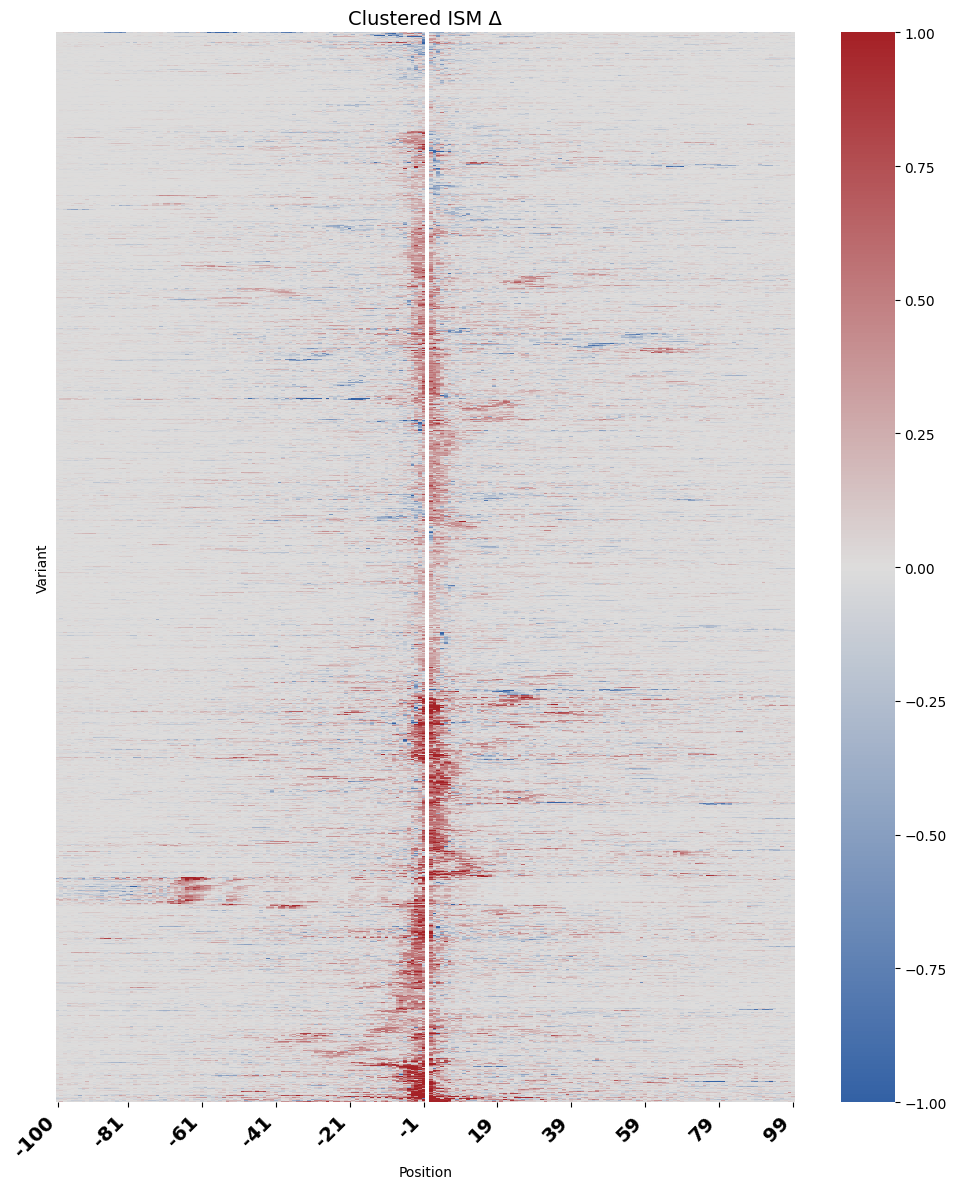

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import LinearSegmentedColormap


# --- make heatmap array ---
delta_df_euclidean = delta_df
heatmap_array_euclidean = np.vstack(delta_df_euclidean["ism_scaled"].values)
row_labels = delta_df_euclidean.index.astype(str).tolist()  

# --- Cluster rows by absolute ISM values ---
row_linkage = linkage(heatmap_array_euclidean, method='ward', metric='euclidean')
row_order = leaves_list(row_linkage)

# reorder matrix + labels
heatmap_array_euclidean = heatmap_array_euclidean[row_order]
row_labels = [row_labels[i] for i in row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array_euclidean, dtype=bool)
if heatmap_array_euclidean.shape[1] > 99:  # safety check
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array_euclidean = np.clip(heatmap_array_euclidean, -1, 1)
vmin, vmax = np.min(heatmap_array_euclidean), np.max(heatmap_array_euclidean)
print(f"vmin: {vmin}")
print(f"vmax: {vmax}")

# --- X axis on the heatmap ---
num_positions = heatmap_array_euclidean.shape[1]
positions = np.arange(-num_positions//2, num_positions//2 + num_positions % 2)

# --- Custom diverging colormap ---
coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot heatmap ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array_euclidean,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

xtick_positions = np.linspace(0, num_positions - 1, 11, dtype=int)
xtick_labels = positions[xtick_positions]

plt.title("Clustered ISM Δ", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(xtick_positions + 0.5, xtick_labels, rotation=45, ha="right", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_all_scaled_OT.png", dpi=1200)
plt.show()


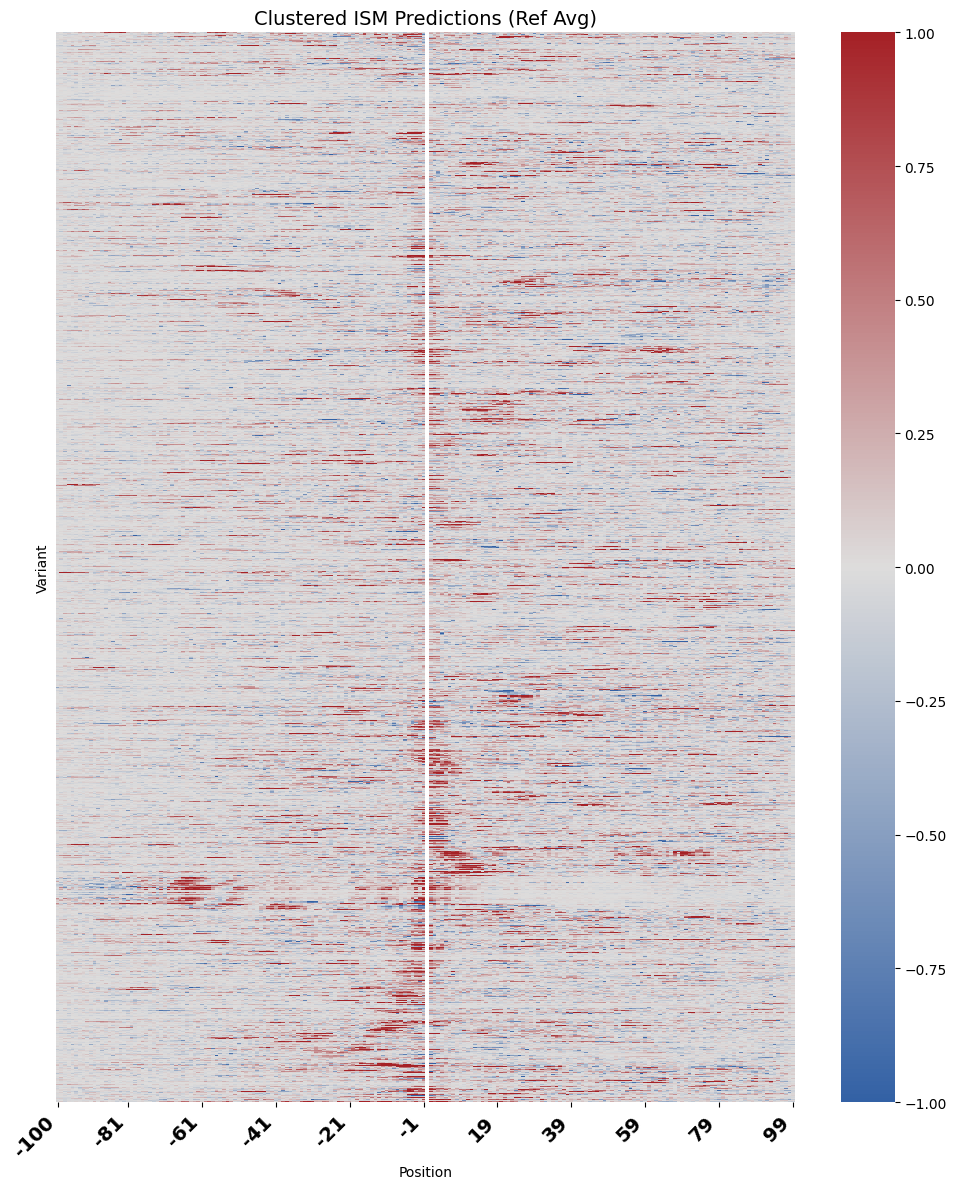

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import ast

# --- Average numeric entries from dicts ---
def avg_numeric_dicts(dict_list):
    vals = []
    for d in dict_list:
        nums = [v for k, v in d.items() if isinstance(v, (int, float))]
        vals.append(np.mean(nums) if nums else np.nan)
    return np.array(vals)

# Apply across all rows
delta_df["ism_predictions_ref"] = delta_df["ism_predictions_ref"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)

ism_ref_avg = delta_df["ism_predictions_ref"].apply(avg_numeric_dicts)

# --- make heatmap array ---
heatmap_array = np.vstack(ism_ref_avg.values)

# --- Cluster rows in the same order as delta ISM ---
heatmap_array = heatmap_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (Ref Avg)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(xtick_positions + 0.5, xtick_labels, rotation=45, ha="right", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_ref_avg.png", dpi=1200)
plt.show()


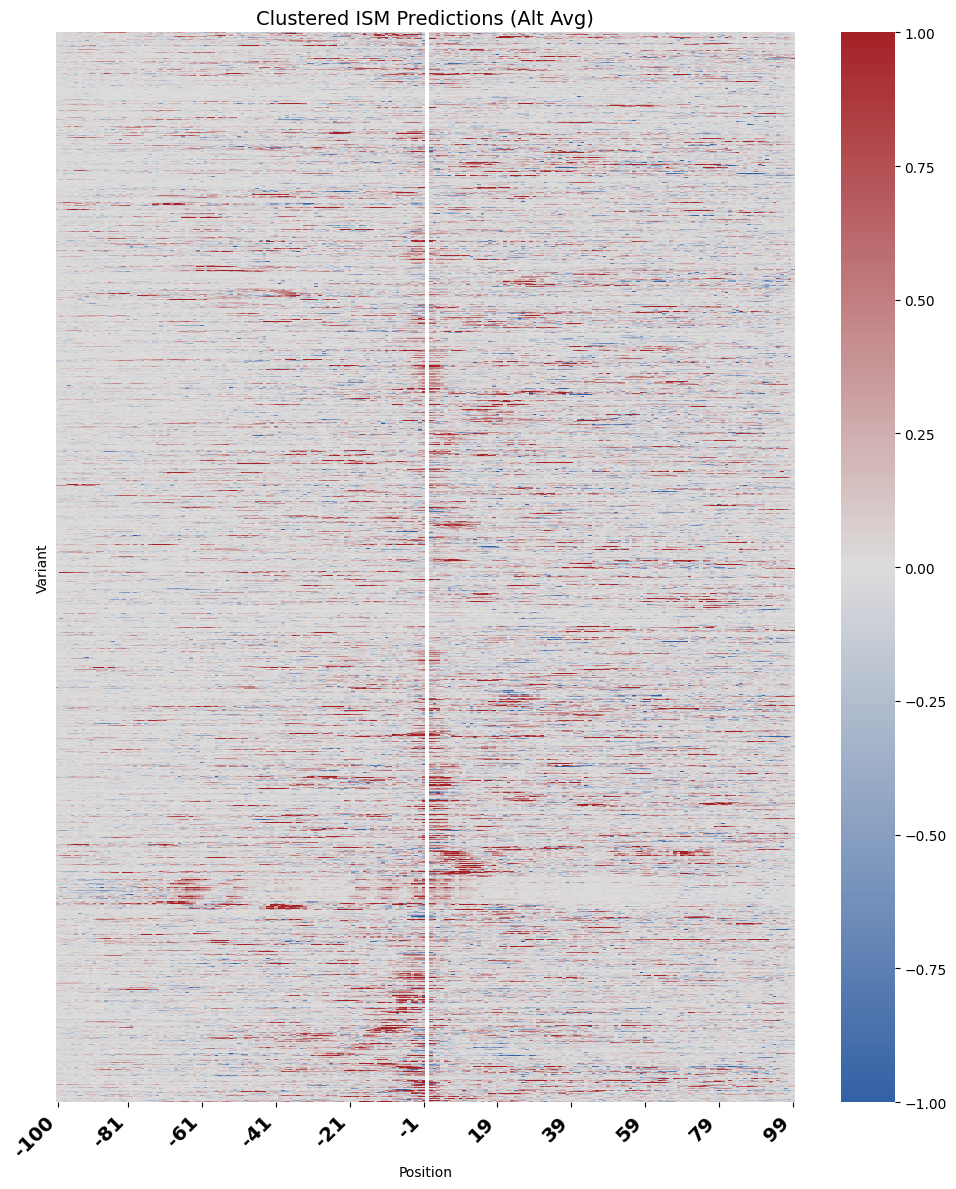

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import ast

# --- Average numeric entries from dicts ---
def avg_numeric_dicts(dict_list):
    vals = []
    for d in dict_list:
        nums = [v for k, v in d.items() if isinstance(v, (int, float))]
        vals.append(np.mean(nums) if nums else np.nan)
    return np.array(vals)

# Apply across all rows
delta_df["ism_predictions_alt"] = delta_df["ism_predictions_alt"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)

ism_alt_avg = delta_df["ism_predictions_alt"].apply(avg_numeric_dicts)

# --- make heatmap array ---
heatmap_array = np.vstack(ism_alt_avg.values)

# --- Cluster rows in the same order as delta ISM ---
heatmap_array = heatmap_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (Alt Avg)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(xtick_positions + 0.5, xtick_labels, rotation=45, ha="right",fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_alt_avg.png", dpi=1200)
plt.show()


In [6]:
# --- Save colorbar as separate SVG ---
fig_cbar, ax_cbar = plt.subplots(figsize=(1.0, 4))  # tall, narrow colorbar
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=custom_cmap),
    cax=ax_cbar
)
cb.ax.tick_params(labelsize=14)
cb.set_label("Δ ISM score", fontsize=16, fontweight="bold")

fig_cbar.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/ism_colorbar.svg",
    format="svg",
    bbox_inches="tight"
)
plt.close(fig_cbar)

plt.show()